In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install neuroCombat

  Preparing metadata (setup.py) ... done
  Created wheel for neuroCombat: filename=neuroCombat-0.2.12-py3-none-any.whl size=6353 sha256=d40910642c0b83e930f9dde3c50c815c76814c3fe87544433f32bc36dc4aa3db
  Stored in directory: /root/.cache/pip/wheels/ab/b2/ba/67ac62c94b5e0adc9bdb835456277052f698d6605a99614cd2
Successfully built neuroCombat


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.svm import SVR
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_curve, auc
from neuroCombat import neuroCombat
import statsmodels.api as sm



# FEMALE DATA

In [ ]:

female_df = pd.read_csv('/content/drive/MyDrive/Thesis_May20th/female_data_updated.csv')

female_covars = {
    "batch": female_df['site_id'],
    "age": female_df['age']
}

covars = pd.DataFrame(female_covars)

columns_to_harmonize = female_df.columns[5:154]  # Adjust or use column names
fdata_to_harmonize = female_df[columns_to_harmonize].values.T

# NeuroCombat
data_harmonized_female = neuroCombat(
    dat=fdata_to_harmonize,
    covars=covars,
    eb=False,
    continuous_cols=["age"],
    batch_col="batch"
)["data"].T


[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding L/S adjustments without Empirical Bayes
[neuroCombat] Final adjustment of data


In [ ]:
print(data_harmonized_female.shape)


(3608, 149)


In [ ]:
print("Harmonized data shape:", data_harmonized_female.shape)
print("Original data shape:", female_df.shape)


Harmonized data shape: (3608, 149)
Original data shape: (3608, 155)


In [ ]:
harmonized_df = pd.DataFrame(data_harmonized_female, columns=columns_to_harmonize, index=female_df.index)


In [ ]:
female_df.update(harmonized_df)


In [ ]:
print(female_df.head())


   Unnamedd  age  gender  site_id  diagnosis  L_G.S_cingul.Ant  \
0        13   14       0        0          0          2.673145   
1        18   26       0        0          0          2.824897   
2        19   21       0        0          0          2.988266   
3        25   68       0        1          0          2.653800   
4        26   19       0        1          0          3.093792   

   L_G.S_cingul.Mid.Ant  L_G.S_cingul.Mid.Post  L_G.S_frontomargin  \
0              2.722372               2.594011            2.323133   
1              2.970105               2.691693            2.393077   
2              2.835668               2.828455            2.649030   
3              2.726183               2.394992            2.386627   
4              2.766954               2.703397            2.083676   

   L_G.S_occipital_inf  ...  R_S_postcentral  R_S_precentral.inf.part  \
0             2.568801  ...         2.420257                 2.445858   
1             2.581216  ...         

In [ ]:
diagnosis_0_data = female_df[female_df['diagnosis'] == 0]

diagnosis_not_0_data = female_df[female_df['diagnosis'] != 0]

train_data = diagnosis_0_data.copy()

total_data_count = len(female_df)
desired_train_size = int(0.8 * total_data_count)
current_train_size = len(train_data)

test_size = total_data_count - desired_train_size

_, test_data_not_0 = train_test_split(diagnosis_not_0_data, test_size=test_size, random_state=42)

test_data = pd.concat([test_data_not_0])

train_size = len(train_data)
test_size = len(test_data)

train_size, test_size


ValueError: test_size=722 should be either positive and smaller than the number of samples 200 or a float in the (0, 1) range

In [ ]:
required_test_size_from_diagnosis_0 = max(0, test_size - len(diagnosis_not_0_data))

if required_test_size_from_diagnosis_0 > 0:
    train_data_diagnosis_0, test_data_diagnosis_0 = train_test_split(
        diagnosis_0_data, test_size=required_test_size_from_diagnosis_0, random_state=42
    )
else:
    train_data_diagnosis_0 = diagnosis_0_data
    test_data_diagnosis_0 = pd.DataFrame()

test_data = pd.concat([test_data_diagnosis_0, diagnosis_not_0_data])

train_data = train_data_diagnosis_0

final_train_size = len(train_data)
final_test_size = len(test_data)

final_train_size, final_test_size


(2886, 722)

In [ ]:
features = [col for col in train_data.columns if col != 'age']
X_train = train_data[features]
y_train = train_data['age']
X_test = test_data[features]
y_test = test_data['age']


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
features = female_df.drop('age', axis=1)
numerical_columns = features.select_dtypes(include=['int64', 'float64']).columns.tolist()

imputer = SimpleImputer(strategy='median')
features[numerical_columns] = imputer.fit_transform(features[numerical_columns])


scaler = StandardScaler()
features[numerical_columns] = scaler.fit_transform(features[numerical_columns])




In [ ]:
imputer = SimpleImputer(strategy='mean')
train_data[numerical_columns] = imputer.fit_transform(train_data[numerical_columns])
test_data[numerical_columns] = imputer.transform(test_data[numerical_columns])

In [ ]:
min_max_scaler = MinMaxScaler()
train_data[numerical_columns] = min_max_scaler.fit_transform(train_data[numerical_columns])
test_data[numerical_columns] = min_max_scaler.transform(test_data[numerical_columns])


# New XGBoost + K-Fold

In [ ]:
xg_reg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=3, seed=42)

xg_reg.fit(X_train, y_train)

y_pred = xg_reg.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared: {r_squared}")
print(f'Mean Squared Error: {mse}')

Root Mean Squared Error (RMSE): 6.495013726469052
Mean Absolute Error (MAE): 4.5871727539231575
R-squared: 0.9298154334183624
Mean Squared Error: 42.1852033070214


MSE scores: [175.08670382229147, 149.23533172484258, 45.613775987810214, 599.5286829762955, 48.461807677450295, 34.93419320015514, 102.71680793576954, 78.91849602373983, 145.46149731178892, 64.07630943804247]
Average MSE: 144.40336060981858
MAE scores: [12.77391654807884, 11.403646641489566, 5.3362433663729965, 20.83903554413054, 5.262820506918019, 4.72910923129516, 6.687052016045637, 5.771223380130792, 8.938949935043915, 6.32634371977586]


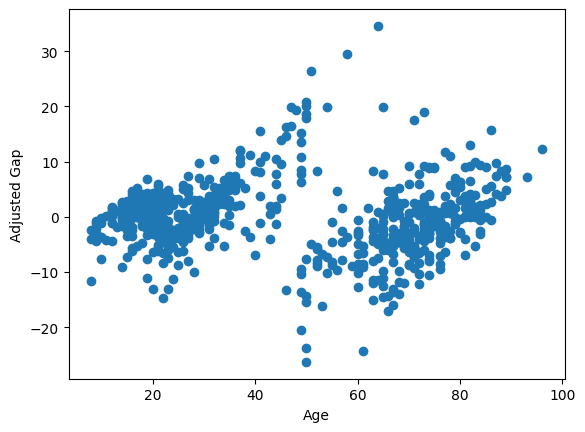

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error
import statsmodels.api as sm
import matplotlib.pyplot as plt


imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Group K-Fold
gkf = GroupKFold(n_splits=10)

groups = X_train['site_id']  # Ensure 'site_id' is available in your X_train

mse_scores = []
mae_scores = []

for train_index, test_index in gkf.split(X_train_imputed, y_train, groups):
    X_train_cv, X_test_cv = X_train_imputed[train_index], X_train_imputed[test_index]
    y_train_cv, y_test_cv = y_train.iloc[train_index], y_train.iloc[test_index]

    X_train_cv = np.nan_to_num(X_train_cv)
    X_test_cv = np.nan_to_num(X_test_cv)
    y_train_cv = y_train_cv.fillna(y_train_cv.mean())
    y_test_cv = y_test_cv.fillna(y_test_cv.mean())

    xg_reg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=3, seed=42)
    xg_reg.fit(X_train_cv, y_train_cv)

    y_pred_cv = xg_reg.predict(X_test_cv)

    mse = mean_squared_error(y_test_cv, y_pred_cv)
    mae = mean_absolute_error(y_test_cv, y_pred_cv)
    mse_scores.append(mse)
    mae_scores.append(mae)

print("MSE scores:", mse_scores)
print("Average MSE:", np.mean(mse_scores))
print("MAE scores:", mae_scores)

xg_reg.fit(X_train_imputed, y_train)
y_pred = xg_reg.predict(X_test_imputed)
gap = y_test - y_pred

age_with_intercept = sm.add_constant(test_data['age'], prepend=False)
mod = sm.OLS(gap, age_with_intercept)
gap_adjusted = mod.fit().resid

plt.scatter(test_data['age'], gap_adjusted)
plt.xlabel('Age')
plt.ylabel('Adjusted Gap')
plt.show()


In [ ]:
female_df.loc[y_test.index, 'gap'] = gap

In [ ]:
#data['residuals'] = data['residuals'].fillna(data['residuals'].median())

female_df['gap'] = female_df['gap'].fillna(female_df['gap'].mean())


In [ ]:
import pandas as pd
from sklearn.metrics import roc_auc_score


for i in range(1, 6):
    female_df[f'diagnosis_{i}_vs_0'] = (female_df['diagnosis'] == i).astype(int)

roc_auc_scores = {}
for i in range(1, 6):
    condition = female_df['diagnosis'].isin([0, i])
    roc_auc_scores[f'ROC AUC for 0 vs {i}'] = roc_auc_score(female_df.loc[condition, f'diagnosis_{i}_vs_0'], female_df.loc[condition, 'gap'])

for key, value in roc_auc_scores.items():
    print(f"{key}: {value:.2f}")


ROC AUC for 0 vs 1: 0.52
ROC AUC for 0 vs 2: 0.61
ROC AUC for 0 vs 3: 0.44
ROC AUC for 0 vs 4: 0.45
ROC AUC for 0 vs 5: 0.50
